# Pipeline MCT-Net Complet — Sentinel-2 → Classification de cultures
## Étape 1 : Alignement CDL  →  Étape 2 : Cube spectral 10 bandes  →  Étape 3 : Entraînement MCT-Net

> **Structure de dossiers attendue (identique à ton projet sentinel2_Lyna) :**
> ```
> data/
>   raw/
>     sentinel2/          ← tes archives .SAFE ici
>     cdl/
>       cdl_california_2021.tif
>   processed/            ← créé automatiquement
> models/                 ← créé automatiquement
> ```

---
## 📦 Imports

In [39]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
print(f'GPU dispo: {"✅ " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️  CPU uniquement"}')
print('✓ Imports OK')

PyTorch  : 2.11.0+cpu
Rasterio : 1.4.4
GPU dispo: ⚠️  CPU uniquement
✓ Imports OK


---
## ⚙️ Configuration — À MODIFIER selon ton projet
> **⚠️ Adapte uniquement cette cellule. Le reste s'exécute automatiquement.**

In [40]:
# ── Chemins principaux ───────────────────────────────────────────────────────
DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
CDL_INPUT = DATA_DIR / 'processed' / 'cdl_california_2021.tif'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')

# ── Fichiers générés automatiquement ────────────────────────────────────────
CDL_ALIGNED   = PROCESSED_DIR / 'california.tif'
TRAIN_CSV     = PROCESSED_DIR / 'mctnet_train_data_10bands.csv'
MODEL_PATH    = MODEL_DIR / 'mctnet_multispectral_final.pth'

# ── Bande S2 de référence pour l'alignement CDL (Étape 1) ───────────────────
# Utilise california1.SAFE comme référence (T10SGH, 20210720)
S2_REF_BAND = (
    SAFE_DIR /
    'california1.SAFE' /
    'GRANULE' /
    'L2A_T10SGH_A022833_20210720T185324' /
    'IMG_DATA' / 'R10m' /
    'T10SGH_20210720T183919_B04_10m.jp2'
)

# ── Mapping des dates → dossiers SAFE ───────────────────────────────────────
# California (tuile T10SGH / T10SFG / T10SFJ)
DATES_MAP = {
    'july_sgh':  ('california1.SAFE', 'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919'),
    'july_sgh2': ('california2.SAFE', 'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919'),
    'jan_sgh':   ('california3.SAFE', 'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641'),
    'sept_sgh':  ('california4.SAFE', 'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959'),
    'jan_sfg':   ('california5.SAFE', 'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641'),
    'sept_sfg':  ('california6.SAFE', 'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131'),
    'apr_sfg':   ('california7.SAFE', 'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911'),
    'july_sfg':  ('california8.SAFE', 'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919'),
    'july_sfj':  ('california9.SAFE', 'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919'),
}

# ── Bandes spectrales ────────────────────────────────────────────────────────
BANDS_10M  = ['B02', 'B03', 'B04', 'B08']
BANDS_20M  = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS  = BANDS_10M + BANDS_20M   # 10 bandes

# ── Hyperparamètres entraînement (Étape 3) ───────────────────────────────────
N_DATES    = 9
N_BANDS    = 10
BATCH_SIZE = 512
LR         = 0.0005
EPOCHS     = 50
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

# ── Création des dossiers ────────────────────────────────────────────────────
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Vérification des fichiers sources ────────────────────────────────────────
print('=== Vérification des chemins ===')
for path, label in [(S2_REF_BAND, 'Bande S2 référence'), (CDL_INPUT, 'CDL brut')]:
    print(f'  {"✅" if Path(path).exists() else "❌ INTROUVABLE"}  {label} : {path}')
print(f'\n  Device     : {DEVICE}')
print(f'  Dates      : {list(DATES_MAP.keys())}')
print(f'  Bandes     : {ALL_BANDS}')
print(f'  Features   : {N_DATES} × {N_BANDS} = {N_DATES * N_BANDS} colonnes')

=== Vérification des chemins ===
  ✅  Bande S2 référence : data\raw\california1.SAFE\GRANULE\L2A_T10SGH_A022833_20210720T185324\IMG_DATA\R10m\T10SGH_20210720T183919_B04_10m.jp2
  ✅  CDL brut : data\processed\cdl_california_2021.tif

  Device     : cpu
  Dates      : ['july_sgh', 'july_sgh2', 'jan_sgh', 'sept_sgh', 'jan_sfg', 'sept_sfg', 'apr_sfg', 'july_sfg', 'july_sfj']
  Bandes     : ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
  Features   : 9 × 10 = 90 colonnes


---
# ÉTAPE 1 — Alignement du CDL sur la grille Sentinel-2
Reprojection du CDL California 2021 vers le CRS et la résolution de ta bande S2 de référence.

### 🔍 Inspection des fichiers sources

In [41]:
with rasterio.open(S2_REF_BAND) as s2:
    print('=== Bande S2 de référence ===')
    print(f'  CRS       : {s2.crs}')
    print(f'  Transform : {s2.transform}')
    print(f'  Taille    : {s2.width} × {s2.height} px')
    print(f'  Bounds    : {s2.bounds}')
    dst_crs       = s2.crs
    dst_transform = s2.transform
    s2_profile    = s2.profile

with rasterio.open(CDL_INPUT) as src:
    print('\n=== CDL brut ===')
    print(f'  CRS       : {src.crs}')
    print(f'  Taille    : {src.width} × {src.height} px')
    print(f'  Bounds    : {src.bounds}')

=== Bande S2 de référence ===
  CRS       : EPSG:32610
  Transform : | 10.00, 0.00, 699960.00|
| 0.00,-10.00, 4300020.00|
| 0.00, 0.00, 1.00|
  Taille    : 10980 × 10980 px
  Bounds    : BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)

=== CDL brut ===
  CRS       : EPSG:5070
  Taille    : 29125 × 41541 px
  Bounds    : BoundingBox(left=-2356095.0, bottom=1212375.0, right=-1482345.0, top=2458605.0)


### 🔄 Reprojection CDL → grille S2 (≈ 1-2 min)

In [42]:
import gc, os

# ── Fermer et libérer le fichier si déjà ouvert ──────────────────────────────
gc.collect()  # libère les objets rasterio encore en mémoire

if CDL_ALIGNED.exists():
    try:
        CDL_ALIGNED.unlink()
        print(f'🗑️  Ancien fichier supprimé : {CDL_ALIGNED}')
    except PermissionError:
        print('⚠️  Fichier encore verrouillé — redémarrez le kernel Jupyter (Kernel > Restart)')

# ── Alignement ───────────────────────────────────────────────────────────────
print("Démarrage de l'alignement forcé... (Patientez environ 1-2 min)")

s2_profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})

with rasterio.open(CDL_INPUT) as src:
    with rasterio.open(CDL_ALIGNED, 'w', **s2_profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=WarpResampling.nearest
        )

print(f'\n✅ CDL aligné créé : {CDL_ALIGNED}')

🗑️  Ancien fichier supprimé : data\processed\california.tif
Démarrage de l'alignement forcé... (Patientez environ 1-2 min)

✅ CDL aligné créé : data\processed\california.tif


### ✅ Vérification du CDL aligné

=== CDL aligné ===
  CRS       : EPSG:32610
  Taille    : 10980 × 10980 px

  Classes agricoles : 55
  Pixels agricoles  : 120,560,400


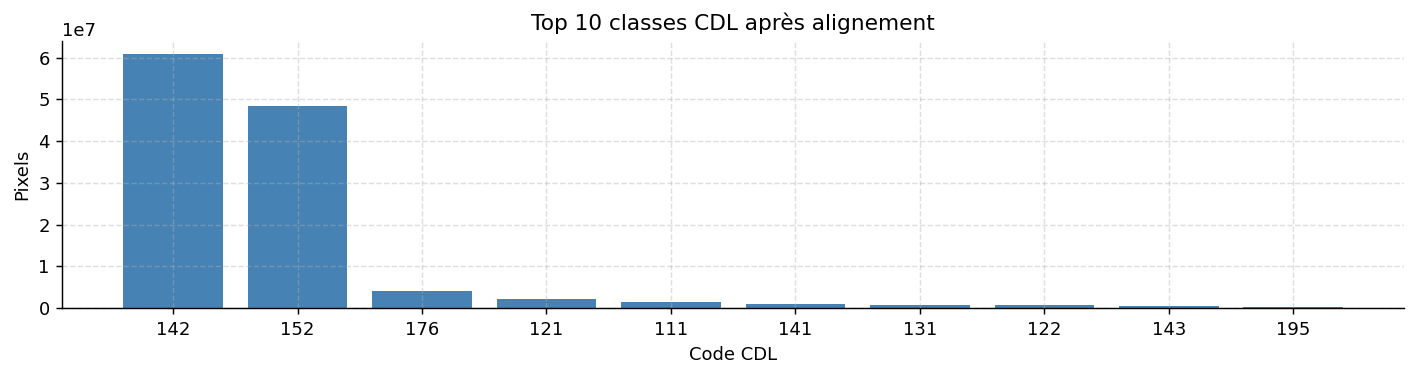


✅ Étape 1 terminée — CDL aligné OK


In [43]:
with rasterio.open(CDL_ALIGNED) as dst:
    print('=== CDL aligné ===')
    print(f'  CRS       : {dst.crs}')
    print(f'  Taille    : {dst.width} × {dst.height} px')
    cdl_check = dst.read(1)

unique_cls, counts_cls = np.unique(cdl_check[cdl_check > 0], return_counts=True)
print(f'\n  Classes agricoles : {len(unique_cls)}')
print(f'  Pixels agricoles  : {counts_cls.sum():,}')

# Top 10 classes
fig, ax = plt.subplots(figsize=(11, 3))
top10 = sorted(zip(counts_cls, unique_cls), reverse=True)[:10]
top_cnt, top_cls = zip(*top10)
ax.bar([str(int(c)) for c in top_cls], top_cnt, color='steelblue')
ax.set_title('Top 10 classes CDL après alignement')
ax.set_xlabel('Code CDL')
ax.set_ylabel('Pixels')
plt.tight_layout()
plt.show()
print('\n✅ Étape 1 terminée — CDL aligné OK')

---
# ÉTAPE 2 — Construction du Cube Spectral (7 dates × 10 bandes)
Extraction des 70 colonnes spectrales pour 50 000 pixels agricoles → CSV.

### 🔧 Fonction utilitaire — Chemin vers une bande .jp2

In [44]:
# ── Fonction get_band_path corrigée ─────────────────────────────────────────
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    """
    Construit le chemin complet vers un fichier .jp2 dans la structure SAFE.
    file_prefix : ex 'T10SGH_20210720T183919' (extrait du nom de fichier réel)
    """
    dir_path = (
        SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir /
        'IMG_DATA' / f'R{res}m'
    )
    filename = f'{file_prefix}_{band}_{res}m.jp2'
    return dir_path / filename
for date_name, (safe_dir, granule_dir, file_prefix) in DATES_MAP.items():
    res  = 10  # B04 est en 10m
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', res)
    status = '✅' if path.exists() else '❌'
    print(f'{status} {date_name:12} → {path.name}')

# Test rapide

✅ july_sgh     → T10SGH_20210720T183919_B04_10m.jp2
✅ july_sgh2    → T10SGH_20210720T183919_B04_10m.jp2
✅ jan_sgh      → T10SGH_20210126T184641_B04_10m.jp2
✅ sept_sgh     → T10SGH_20210921T184959_B04_10m.jp2
✅ jan_sfg      → T10SFG_20210126T184641_B04_10m.jp2
✅ sept_sfg     → T10SFG_20210926T185131_B04_10m.jp2
✅ apr_sfg      → T10SFG_20210419T184911_B04_10m.jp2
✅ july_sfg     → T10SFG_20210723T184919_B04_10m.jp2
✅ july_sfj     → T10SFJ_20210723T184919_B04_10m.jp2


### 🗺️ Lecture du CDL & Échantillonnage de 50 000 pixels agricoles

In [45]:
print('Analyse du CDL et échantillonnage...')
np.random.seed(RANDOM_STATE)

with rasterio.open(CDL_ALIGNED) as src:
    labels       = src.read(1)
    target_shape = labels.shape

agri_mask    = (labels > 0)
agri_indices = np.where(agri_mask)
total_agri   = len(agri_indices[0])

num_samples    = min(total_agri, 50_000)
sample_indices = np.random.choice(range(total_agri), num_samples, replace=False)
final_rows     = agri_indices[0][sample_indices]
final_cols     = agri_indices[1][sample_indices]
y_final        = labels[final_rows, final_cols]

df_final = pd.DataFrame({'crop_label': y_final})

print(f'  Taille grille CDL    : {target_shape}')
print(f'  Pixels agricoles     : {total_agri:,}')
print(f'  Pixels échantillonnés: {num_samples:,}')
print(f'  Classes uniques      : {len(np.unique(y_final))}')
print('\n✅ Échantillonnage OK')

Analyse du CDL et échantillonnage...
  Taille grille CDL    : (10980, 10980)
  Pixels agricoles     : 120,560,400
  Pixels échantillonnés: 50,000
  Classes uniques      : 25

✅ Échantillonnage OK


### 📡 Extraction des 70 bandes spectrales (7 dates × 10 bandes)
> Les bandes 20m sont automatiquement rééchantillonnées à 10m (bilinéaire).

In [46]:
for date_name, (safe_dir_name, granule_dir, sensing_dt) in DATES_MAP.items():
    print(f'\n📅 {date_name.upper()}')
    for band in ALL_BANDS:
        res  = 10 if band in BANDS_10M else 20
        path = get_band_path(safe_dir_name, granule_dir, sensing_dt, band, res)
        if not path.exists():
            print(f'  ❌ {band} INTROUVABLE')
            continue
        with rasterio.open(path) as src:
            data = src.read(1, out_shape=target_shape, resampling=Resampling.bilinear)
            df_final[f'{band}_{date_name}'] = data[final_rows, final_cols].astype('float32')
        print(f'  ✅ {band}', end=' | ')
    print()

print(f'\nDimensions : {df_final.shape}  ({len(df_final):,} pixels × {df_final.shape[1]} colonnes)')


📅 JULY_SGH
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JULY_SGH2
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 SEPT_SGH
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 SEPT_SFG
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 APR_SFG
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JULY_SFG
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JULY_SFJ
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B1

### 💾 Sauvegarde du CSV

✅ CSV sauvegardé : data\processed\mctnet_train_data_10bands.csv  (30.3 MB)


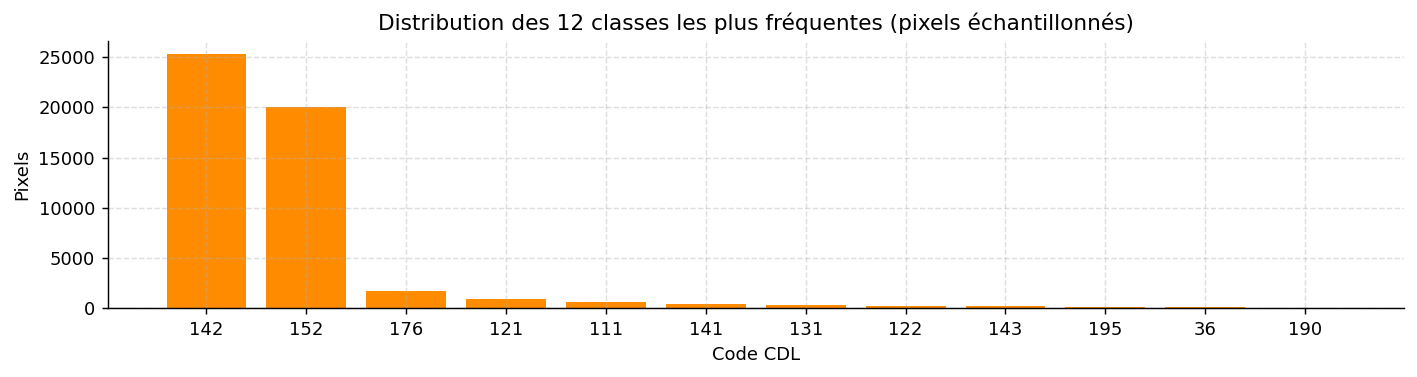


✅ Étape 2 terminée — CSV OK


In [47]:
df_final.to_csv(TRAIN_CSV, index=False)
size_mb = TRAIN_CSV.stat().st_size / 1e6
print(f'✅ CSV sauvegardé : {TRAIN_CSV}  ({size_mb:.1f} MB)')

# Aperçu distribution
label_counts = df_final['crop_label'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(label_counts.index.astype(str), label_counts.values, color='darkorange')
ax.set_title('Distribution des 12 classes les plus fréquentes (pixels échantillonnés)')
ax.set_xlabel('Code CDL')
ax.set_ylabel('Pixels')
plt.tight_layout()
plt.show()
print('\n✅ Étape 2 terminée — CSV OK')

---
# ÉTAPE 3 — Entraînement du modèle MCT-Net (CNN + Transformer)
Entrée : `(Batch, 7 dates, 10 bandes)` → Sortie : classe de culture

### 📊 Chargement & Préparation des données

In [48]:
print('Lecture du dataset...')
df = pd.read_csv(TRAIN_CSV)
print(f'  Lignes   : {len(df):,}')
print(f'  Colonnes : {df.shape[1]}')
print(f'  Classes  : {df["crop_label"].nunique()} cultures uniques')

# Encodage labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['crop_label'])
num_classes = len(le.classes_)
print(f'\n  → {num_classes} classes encodées : {list(le.classes_[:8])} ...')

# Features & labels
X = df.drop(['crop_label', 'label_encoded'], axis=1).values
y = df['label_encoded'].values

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Reshape : (N, 70) → (N, 7 dates, 10 bandes)
X_train = X_train.reshape(-1, N_DATES, N_BANDS)
X_test  = X_test.reshape(-1, N_DATES, N_BANDS)

train_data   = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

print(f'\n  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  Batches par époque : {len(train_loader)}')

Lecture du dataset...
  Lignes   : 50,000
  Colonnes : 91
  Classes  : 25 cultures uniques

  → 25 classes encodées : [np.int64(24), np.int64(36), np.int64(37), np.int64(42), np.int64(61), np.int64(68), np.int64(69), np.int64(76)] ...

  X_train : (40000, 9, 10)
  X_test  : (10000, 9, 10)
  Batches par époque : 79


### 🧠 Architecture MCT-Net (CNN 1D + Transformer Encoder)

In [49]:
class CNNTransformerMCTNet(nn.Module):
    """
    Modèle hybride CNN 1D + Transformer pour séries temporelles multi-spectrales.

    Flux :
      (Batch, 7, 10)  → transpose → (Batch, 10, 7)
      CNN 1D          → (Batch, 128, 7)
      transpose       → (Batch, 7, 128)
      Transformer     → (Batch, 7, 128)
      GlobalAvgPool   → (Batch, 128)
      Linear          → (Batch, num_classes)
    """
    def __init__(self, num_classes, cnn_filters=128, nhead=8, num_layers=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=N_BANDS, out_channels=cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU()
        )
        encoder_layer    = nn.TransformerEncoderLayer(d_model=cnn_filters, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc          = nn.Linear(cnn_filters, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)      # (B, 10, 7)
        x = self.cnn(x)            # (B, 128, 7)
        x = x.transpose(1, 2)      # (B, 7, 128)
        x = self.transformer(x)    # (B, 7, 128)
        x = x.mean(dim=1)          # (B, 128)  — Global Average Pooling
        return self.fc(x)          # (B, num_classes)

model = CNNTransformerMCTNet(num_classes=num_classes).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Modèle MCT-Net initialisé')
print(f'  Paramètres : {total_params:,}')
print(f'  Classes    : {num_classes}')
print(f'  Device     : {DEVICE}')
print(model)

Modèle MCT-Net initialisé
  Paramètres : 1,786,521
  Classes    : 25
  Device     : cpu
CNNTransformerMCTNet(
  (cnn): Sequential(
    (0): Conv1d(10, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=Fal

### 🏋️ Boucle d'entraînement (50 époques)

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
history   = {'loss': [], 'accuracy': []}

print(f'Entraînement MCT-Net — {num_classes} classes, entrée ({N_DATES} dates × {N_BANDS} bandes)')
print(f'Device : {DEVICE}  |  Batch : {BATCH_SIZE}  |  LR : {LR}  |  Époques : {EPOCHS}\n')

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    acc = 100 * correct / total
    history['loss'].append(total_loss / len(train_loader))
    history['accuracy'].append(acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'  Époque [{epoch+1:>2}/{EPOCHS}]  Loss : {history["loss"][-1]:.4f}  Acc : {acc:.2f}%')

print('\n✅ Entraînement terminé !')

Entraînement MCT-Net — 25 classes, entrée (9 dates × 10 bandes)
Device : cpu  |  Batch : 512  |  LR : 0.0005  |  Époques : 50

  Époque [ 1/50]  Loss : 0.9194  Acc : 70.77%
  Époque [ 5/50]  Loss : 0.5775  Acc : 80.95%
  Époque [10/50]  Loss : 0.5100  Acc : 82.42%
  Époque [15/50]  Loss : 0.4743  Acc : 83.26%
  Époque [20/50]  Loss : 0.4328  Acc : 84.25%
  Époque [25/50]  Loss : 0.3917  Acc : 85.58%
  Époque [30/50]  Loss : 0.3459  Acc : 87.18%
  Époque [35/50]  Loss : 0.2959  Acc : 89.14%
  Époque [40/50]  Loss : 0.2364  Acc : 91.01%
  Époque [45/50]  Loss : 0.1859  Acc : 92.98%
  Époque [50/50]  Loss : 0.1618  Acc : 93.90%

✅ Entraînement terminé !


### 📈 Courbes Loss & Accuracy

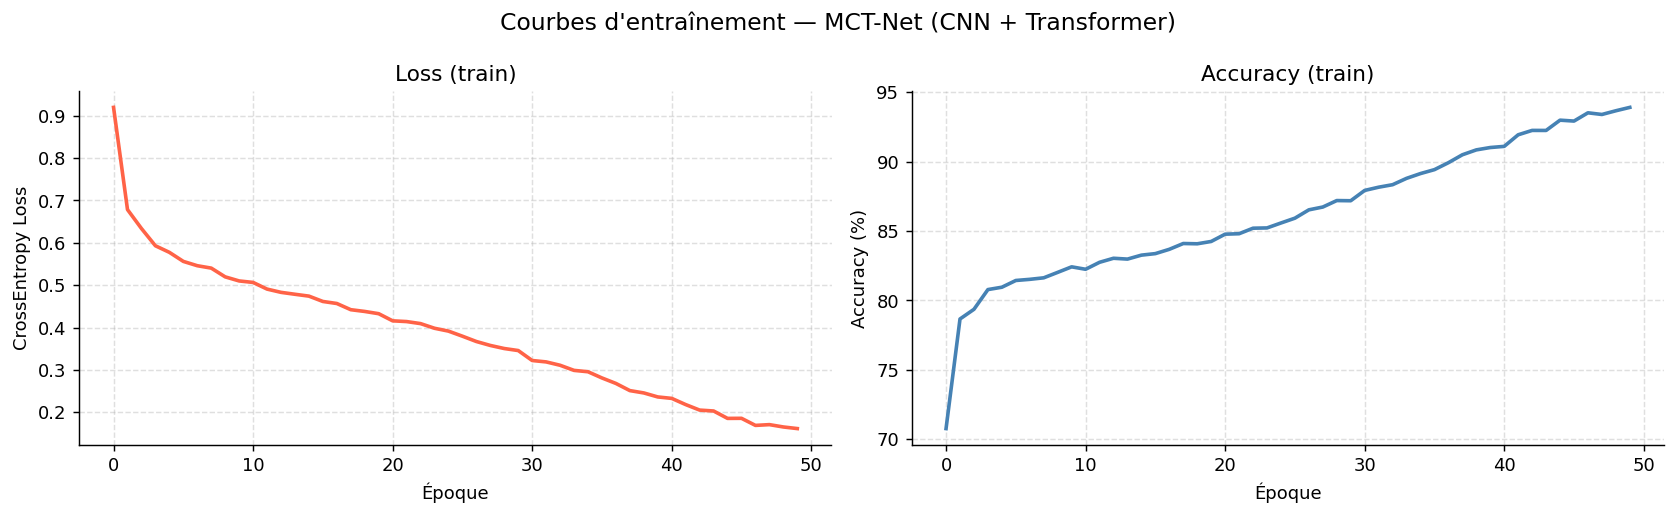

Loss finale  : 0.1618
Acc finale   : 93.90%


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['loss'], color='tomato', linewidth=2)
axes[0].set_title('Loss (train)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('CrossEntropy Loss')

axes[1].plot(history['accuracy'], color='steelblue', linewidth=2)
axes[1].set_title('Accuracy (train)')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy (%)')

plt.suptitle('Courbes d\'entraînement — MCT-Net (CNN + Transformer)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Loss finale  : {history["loss"][-1]:.4f}')
print(f'Acc finale   : {history["accuracy"][-1]:.2f}%')

### 🧪 Évaluation sur le jeu de test

In [52]:
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    test_acc = 100 * (predicted == y_test_t).sum().item() / len(y_test_t)

print(f'\n🎯 Accuracy sur le jeu de TEST : {test_acc:.2f}%')


🎯 Accuracy sur le jeu de TEST : 79.83%


### 💾 Sauvegarde du modèle

In [53]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'num_classes'      : num_classes,
    'label_classes'    : list(le.classes_),
    'history'          : history,
    'test_accuracy'    : test_acc,
    'n_dates'          : N_DATES,
    'n_bands'          : N_BANDS,
}, MODEL_PATH)

print(f'✅ Modèle sauvegardé : {MODEL_PATH}')
print(f'   Accuracy test     : {test_acc:.2f}%')
print('\n🎉 Pipeline MCT-Net complet terminé !')

✅ Modèle sauvegardé : models\mctnet_multispectral_final.pth
   Accuracy test     : 79.83%

🎉 Pipeline MCT-Net complet terminé !
